# Scaling, Reflection and Shear

## Purpose

See how simple 2×2 matrices stretch, flip and shear vectors.

The previous notebook introduced matrix-vector multiplication as a transformation rule.

This notebook looks at three simple transformation types:

- scaling
- reflection
- shear

## Helpers

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_vector_plot(xlim=(-5, 5), ylim=(-5, 5), figsize=(5.5, 5.5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    return fig, ax


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.1, 0.1),
    width=0.007,
):
    origin = np.array(origin, dtype=float)
    v = np.array(v, dtype=float)

    ax.quiver(
        origin[0],
        origin[1],
        v[0],
        v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        width=width,
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10,
        )


def draw_transformation(ax, original, transformed, original_label="v", transformed_label="A @ v"):
    draw_vector(ax, original, label=original_label, label_offset=(0.1, 0.1))
    draw_vector(ax, transformed, label=transformed_label, label_offset=(0.1, -0.35), width=0.01)


def show_matrix_transformation(A, v, title, xlim=(-5, 5), ylim=(-5, 5)):
    transformed_v = A @ v

    fig, ax = setup_vector_plot(xlim=xlim, ylim=ylim)

    draw_vector(ax, v, label="v", label_offset=(0.1, 0.1))
    draw_vector(ax, transformed_v, label="A @ v", label_offset=(0.1, -0.35), width=0.01)

    ax.set_title(title)
    plt.show()

    print("A:")
    print(A)
    print()
    print("v:", v)
    print("A @ v:", transformed_v)

## Scaling both axes

A scaling matrix stretches or shrinks vectors.

For example:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 2
\end{bmatrix}
$$

doubles both the x-component and the y-component.

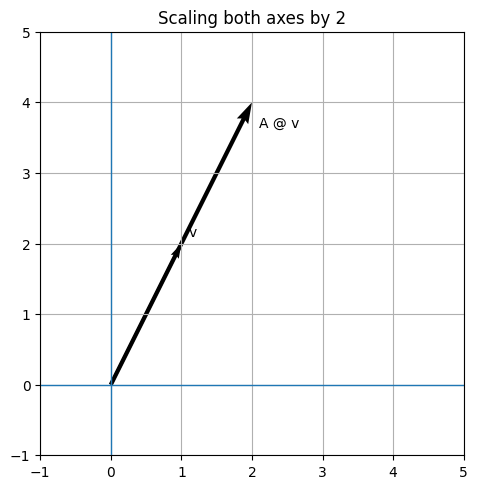

A:
[[2 0]
 [0 2]]

v: [1 2]
A @ v: [2 4]


In [2]:
A = np.array([
    [2, 0],
    [0, 2],
])

v = np.array([1, 2])

show_matrix_transformation(
    A,
    v,
    title="Scaling both axes by 2",
    xlim=(-1, 5),
    ylim=(-1, 5),
)

The vector keeps the same direction, but its length doubles.

This is a uniform scaling.

## Scaling x and y differently

A matrix can also scale the x and y directions by different amounts.

For example:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 0.5
\end{bmatrix}
$$

doubles the x-component but halves the y-component.

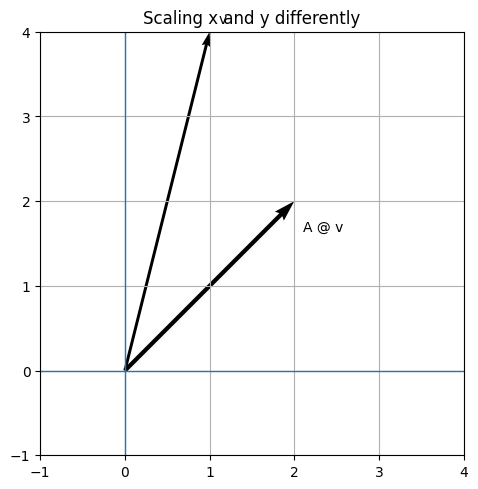

A:
[[2.  0. ]
 [0.  0.5]]

v: [1 4]
A @ v: [2. 2.]


In [8]:
A = np.array([
    [2, 0],
    [0, 0.5],
])

v = np.array([1, 4])

show_matrix_transformation(
    A,
    v,
    title="Scaling x and y differently",
    xlim=(-1, 4),
    ylim=(-1, 4),
)

The vector changes both length and direction because the two axes have been scaled differently.

## Reflection

A reflection flips vectors across an axis.

This matrix reflects across the x-axis:

$$
A =
\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$$

It leaves x unchanged and flips the sign of y.

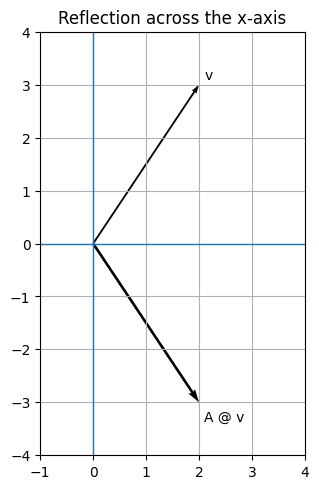

A:
[[ 1  0]
 [ 0 -1]]

v: [2 3]
A @ v: [ 2 -3]


In [4]:
A = np.array([
    [1, 0],
    [0, -1],
])

v = np.array([2, 3])

show_matrix_transformation(
    A,
    v,
    title="Reflection across the x-axis",
    xlim=(-1, 4),
    ylim=(-4, 4),
)

The original vector points upward.

The transformed vector points downward by the same amount.

## Reflection across the y-axis

To reflect across the y-axis, flip the sign of x and leave y unchanged:

$$
A =
\begin{bmatrix}
-1 & 0 \\
0 & 1
\end{bmatrix}
$$

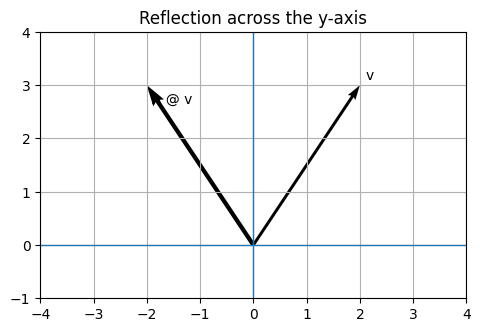

A:
[[-1  0]
 [ 0  1]]

v: [2 3]
A @ v: [-2  3]


In [5]:
A = np.array([
    [-1, 0],
    [0, 1],
])

v = np.array([2, 3])

show_matrix_transformation(
    A,
    v,
    title="Reflection across the y-axis",
    xlim=(-4, 4),
    ylim=(-1, 4),
)

## Shear

A shear slants vectors.

For example:

$$
A =
\begin{bmatrix}
1 & 1 \\
0 & 1
\end{bmatrix}
$$

changes the x-component based on the y-component.

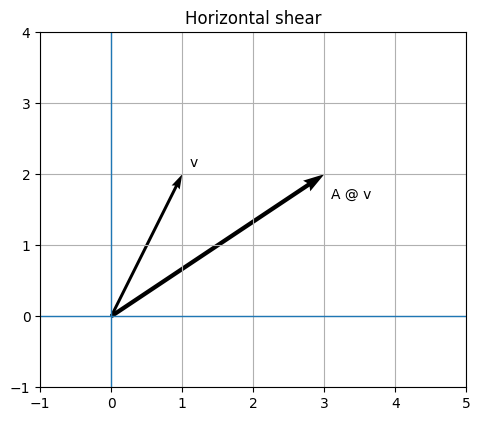

A:
[[1 1]
 [0 1]]

v: [1 2]
A @ v: [3 2]


In [6]:
A = np.array([
    [1, 1],
    [0, 1],
])

v = np.array([1, 2])

show_matrix_transformation(
    A,
    v,
    title="Horizontal shear",
    xlim=(-1, 5),
    ylim=(-1, 4),
)

The y-component stayed the same.

The x-component increased by the value of the y-component.

So:

$$
[1, 2]
\rightarrow
[3, 2]
$$

## Comparing transformations

Here are the same starting vector and several transformations.

In [7]:
v = np.array([1, 2])

transformations = {
    "scale": np.array([[2, 0], [0, 2]]),
    "reflect x-axis": np.array([[1, 0], [0, -1]]),
    "horizontal shear": np.array([[1, 1], [0, 1]]),
}

for name, A in transformations.items():
    print(name)
    print("A @ v =", A @ v)
    print()

scale
A @ v = [2 4]

reflect x-axis
A @ v = [ 1 -2]

horizontal shear
A @ v = [3 2]



The same vector can be transformed in several different ways depending on the matrix.

The matrix is the rule.

## Summary

- Scaling matrices stretch or shrink vectors.
- Reflection matrices flip vectors across an axis.
- Shear matrices slant vectors.
- Different matrices encode different transformation rules.
- The calculation \(A v\) applies the transformation.

## Next step

Next, we will look at rotation matrices.